Compare class_weight vs SMOTE using the same model to isolate the effect. We’ll do this for LogReg and RF

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [3]:
import pandas as pd
from pathlib import Path
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from src.preprocessing import AmountTimeScaler, split_X_y
from src.utils import threshold_for_target_recall, summarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

DATA_PROCESSED = Path("../data/processed")
train = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test  = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")
X, y = split_X_y(train)


In [4]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
TARGET_RECALL = 0.80


In [5]:
setups = {
    "LogReg_classweight": ImbPipeline([
        ("scale", AmountTimeScaler()), 
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "LogReg_SMOTE": ImbPipeline([
        ("scale", AmountTimeScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    "RF_classweight": ImbPipeline([
        ("scale", AmountTimeScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=400, n_jobs=-1, random_state=42,
            class_weight="balanced_subsample"
        ))
    ]),
    "RF_SMOTE": ImbPipeline([
        ("scale", AmountTimeScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(
            n_estimators=400, n_jobs=-1, random_state=42
        ))
    ]),
}


In [6]:
ablation_tables = {}
for name, pipe in setups.items():
    pipe.fit(X_tr, y_tr)
    val_scores = pipe.predict_proba(X_val)[:,1]
    thr = threshold_for_target_recall(y_val, val_scores, TARGET_RECALL)
    tables = []
    for label, df in [("TEST", test), ("STREAM1", stream1), ("STREAM2", stream2)]:
        X_b, y_b = split_X_y(df)
        scores = pipe.predict_proba(X_b)[:,1]
        tables.append(summarize(y_b, scores, thr).assign(batch=label, setup=name))
    ablation_tables[name] = pd.concat(tables, ignore_index=True)

ablation = pd.concat(ablation_tables.values(), ignore_index=True)
ablation


,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct,batch,setup
0,0.001051,0.216374,0.787234,0.339450,0.368661,37,134,9819,10,171,0.0171,TEST,LogReg_classweight
1,0.001051,0.072289,0.666667,0.130435,0.347861,6,77,9914,3,83,0.0083,STREAM1,LogReg_classweight
2,0.001051,0.133333,1.000000,0.235294,0.662630,10,65,9925,0,75,0.0075,STREAM2,LogReg_classweight
3,0.001005,0.123209,0.914894,0.217172,0.409812,43,306,9647,4,349,0.0349,TEST,LogReg_SMOTE
4,0.001005,0.023077,0.666667,0.044610,0.373556,6,254,9737,3,260,0.0260,STREAM1,LogReg_SMOTE
5,0.001005,0.038023,1.000000,0.073260,0.856059,10,253,9737,0,263,0.0263,STREAM2,LogReg_SMOTE
6,0.002500,0.064140,0.936170,0.120055,0.390946,44,642,9311,3,686,0.0686,TEST,RF_classweight
7,0.002500,0.009050,0.666667,0.017857,0.666967,6,657,9334,3,663,0.0663,STREAM1,RF_classweight
8,0.002500,0.013495,1.000000,0.026631,0.911364,10,731,9259,0,741,0.0741,STREAM2,RF_classweight
9,0.002500,0.031208,0.978723,0.060487,0.359563,46,1428,8525,1,1474,0.1474,TEST,RF_SMOTE


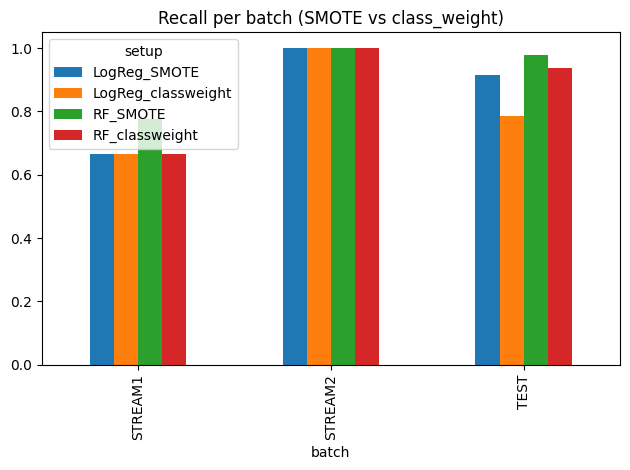

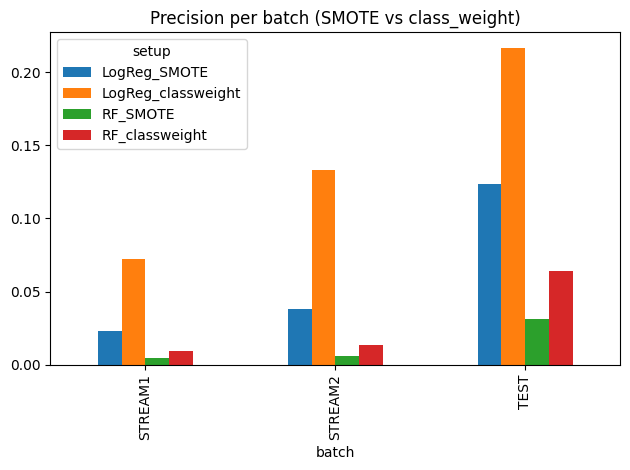

In [7]:
import matplotlib.pyplot as plt

for metric in ["recall", "precision"]:
    p = ablation.pivot(index="batch", columns="setup", values=metric)
    ax = p.plot(kind="bar")
    ax.set_title(f"{metric.capitalize()} per batch (SMOTE vs class_weight)")
    plt.tight_layout()
    plt.show()
